# Spectrogram background image

Renders a pure spectrogram (no axes, no ticks, no colorbar) from a segment of an
audio file, meant to be used as the full-bleed background image of a
quarto/revealjs slide (e.g. via `## Slide title {background-image="..."}`).

In [35]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [36]:
AUDIO_PATH = "./data/Ummet Ozcan - Techno Shaman (Official Music Video) - Ummet Ozcan.mp3"

# --- choose the segment to plot (in seconds) -------------------------------
START_SEC = 60.0
START_SEC = 80.0
END_SEC = 100.0

# .jpg (not .svg): this is dense raster data, not vector line art, so a jpg
# is far smaller than an svg at the same visual quality.
OUT_PATH = "./images/spectrogram_techo.jpg"

In [45]:
y, sr = librosa.load(
    AUDIO_PATH,
    sr=None,
    mono=True,
    offset=START_SEC,
    duration=END_SEC - START_SEC,
)

# high-res STFT: large n_fft for fine frequency detail (crucial for the log
# axis, where low-frequency bins are otherwise coarse), small hop for smooth
# temporal detail.
n_fft = 8192
hop_length = 128

D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

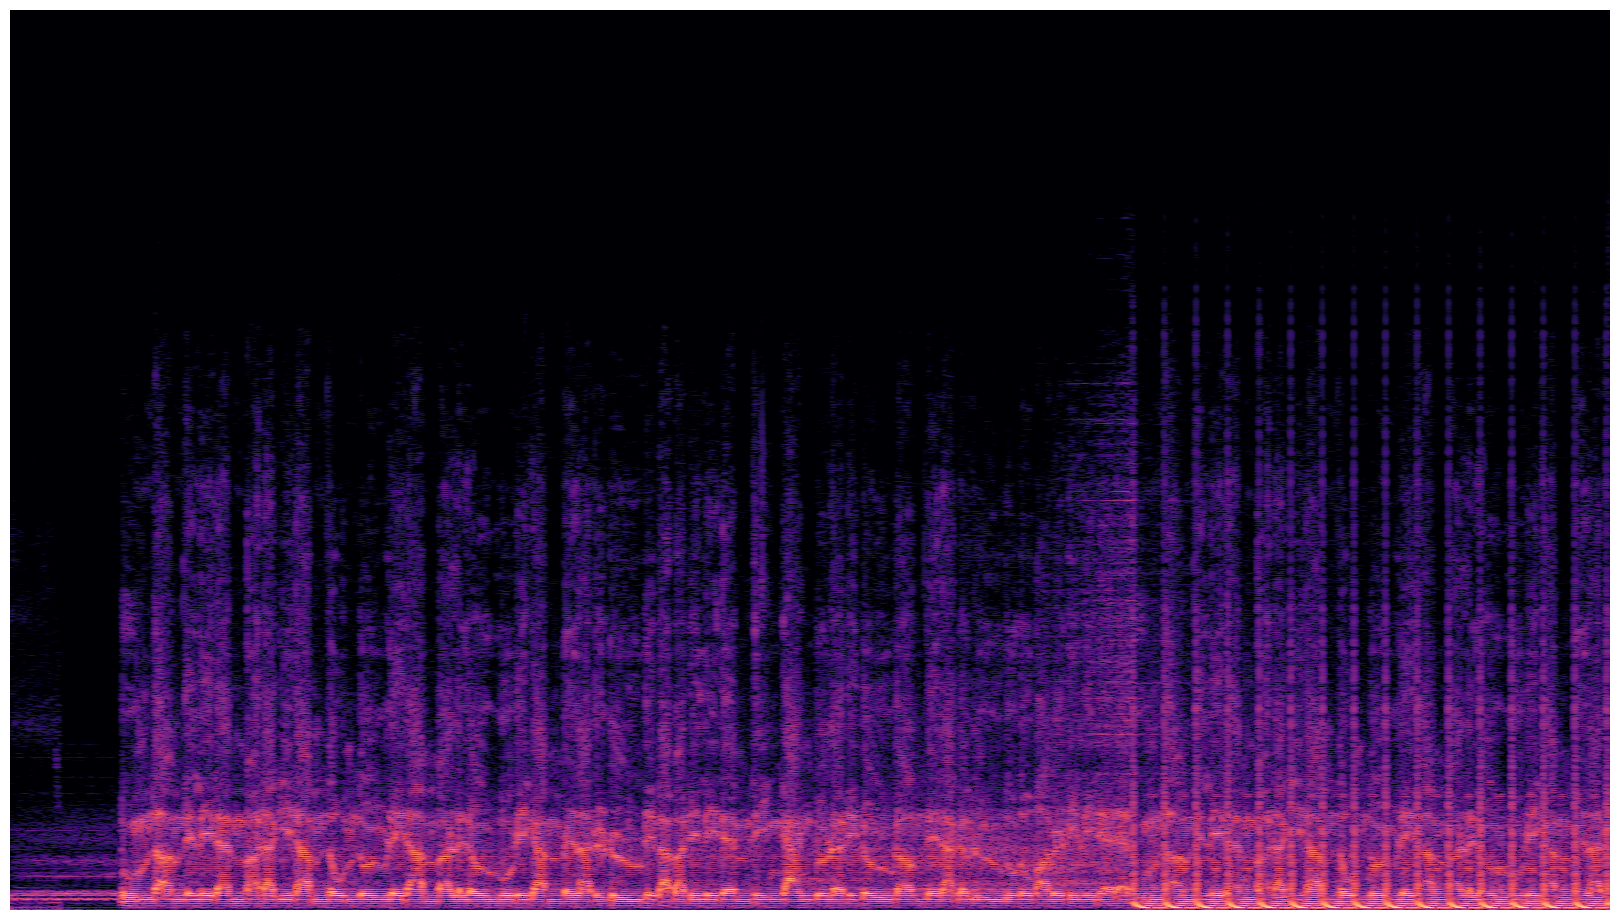

saved: ./images/spectrogram_techo.jpg


In [46]:
fig, ax = plt.subplots(figsize=(16, 9))

librosa.display.specshow(
    S_db, sr=sr, hop_length=hop_length, x_axis=None, cmap="magma", ax=ax
)
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

fig.savefig(OUT_PATH, dpi=300, pad_inches=0, pil_kwargs={"quality": 97})
plt.show()
print("saved:", OUT_PATH)

In [47]:
import soundfile as sf

# save the matching audio excerpt next to the other presentation audio assets,
# so it can be embedded in the slide (e.g. via an <audio> tag) alongside the
# spectrogram background image above.
AUDIO_OUT_PATH = f"./data/techno_shaman_{int(START_SEC)}s-{int(END_SEC)}s.wav"

sf.write(AUDIO_OUT_PATH, y, sr)
print("saved:", AUDIO_OUT_PATH)

saved: ./data/techno_shaman_80s-100s.wav
